In [1]:
import os
import streamlit as st

from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langchain_groq import ChatGroq
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.messages import HumanMessage, SystemMessage
from tavily import TavilyClient
from dotenv import load_dotenv

c:\Users\ok\OneDrive\Documents\Agentic AI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
GROQ_API_KEY= os.getenv("GROQ_API_KEY")
TAVILY_API_KEY= os.getenv("TAVILY_API_KEY")
tavily_client = TavilyClient(api_key=TAVILY_API_KEY)

In [4]:
llm = ChatGroq( 
    model = 'llama-3.3-70b-versatile',
    temperature= 0.7,
    groq_api_key= os.getenv('GROQ_API_KEY')
)

In [5]:
embeddings = HuggingFaceEmbeddings(
    model_name='sentence-transformers/all-MiniLM-L6-v2',
    encode_kwargs={'normalize_embeddings': True}
)

vector_db = FAISS.from_texts(
    ['System: Vector DB Initialized'],
    embeddings
)

C:\Users\ok\AppData\Local\Temp\ipykernel_13940\3847890788.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 299.83it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
class OrchestratorState(TypedDict):
    query : str
    plan : str
    research_data : str
    analysis : str
    citations : str
    final_report : str

In [7]:
def root_orchestrator(state : OrchestratorState):
    '''Acts as the Root Agent coordinating execution state.'''
    return {'query': state['query']}

In [8]:
def planner_agent(state : OrchestratorState):
    response = llm.invoke([
        SystemMessage(content="You are a research assistant. Your task is to create a research plan to answer the given research question. The plan should include the following sections: 1) Research Question, 2) Research Plan, 3) Expected Outcomes. Be concise and clear in your response."),
        HumanMessage(content=f"Research Plan Question for: {state['query']}")
    ])
    return {'plan' : response.content}

In [9]:
def research_agent(state: OrchestratorState):
    # Perform the search
    response = tavily_client.search(
        query=state['query'], 
        search_depth='advanced', 
        max_results=5
    )
    
    # FIX: Use .results (dot notation) instead of ['results'] (bracket notation)
    # The SDK returns an object, not a dictionary.
    results = [f"Title: {item.title}\nContent: {item.content}" for item in response.results]
    
    raw_content = "\n\n".join(results)
    
    # Save to Vector DB
    vector_db.add_texts([raw_content])
    
    return {"research_data": raw_content}

In [10]:
def analysis_agent(state : OrchestratorState):
    '''Analyzes the research data and extracts key insights.'''
    response = llm.invoke([
        SystemMessage(content="You are a research assistant. Your task is to analyze the provided research data and extract key insights relevant to the research question. Be concise and clear in your response."),
        HumanMessage(content=f"Research Data for Analysis: {state['research_data']}")
    ])
    return {'analysis' : response.content}

In [11]:
def citation_agent(state : OrchestratorState):
    '''Generates citations for the research data used in the analysis.'''
    response = llm.invoke([
        SystemMessage(content="You are a research assistant. Your task is to generate citations for the research data used in the analysis. Provide citations in APA format and include the source of the information."),
        HumanMessage(content=f"Research Data for Citation: {state['research_data']}")
    ])
    return {'citations' : response.content}

In [12]:
def format_agent(state : OrchestratorState):
    '''Formats the final report based on the analysis and citations.'''
    docs = vector_db.similarity_search(state['query'], k=3)
    memory_context = docs[0].page_content if docs else 'No relevant documents found.'
    
    prompt = f'''
        Compile the final report based on the following information:
        Plan: {state['plan']},
        Analysis: {state['analysis']},
        Citations: {state['citations']},
        Memory Context: {memory_context}
    '''

    response = llm.invoke([
        SystemMessage(content="You are a research assistant. Your task is to format a final report based on the analysis, citations, and relevant research data. The report should be well-structured and concise."),
        HumanMessage(content=f"Analysis: {state['analysis']}\n\nCitations: {state['citations']}\n\nRelevant Research Data: {memory_context}\n\nFormat the final report based on the above information.")
    ])

    return {'final_report' : response.content}

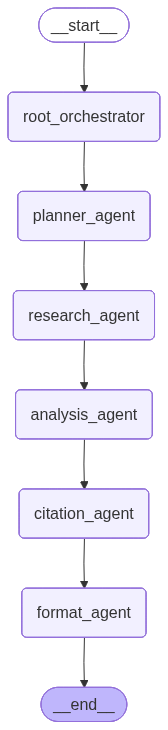

In [13]:
workflow = StateGraph(OrchestratorState)

workflow.add_node('root_orchestrator', root_orchestrator)
workflow.add_node('planner_agent', planner_agent)
workflow.add_node('research_agent', research_agent)
workflow.add_node('analysis_agent', analysis_agent)
workflow.add_node('citation_agent', citation_agent)
workflow.add_node('format_agent', format_agent)

workflow.add_edge(START, 'root_orchestrator')
workflow.add_edge('root_orchestrator', 'planner_agent')
workflow.add_edge('planner_agent', 'research_agent')
workflow.add_edge('research_agent', 'analysis_agent')
workflow.add_edge('analysis_agent', 'citation_agent')
workflow.add_edge('citation_agent', 'format_agent')
workflow.add_edge('format_agent', END)

app = workflow.compile(checkpointer= MemorySaver())
app

In [14]:
# config = {"configurable": {"thread_id": "orchestrator_session_001"}}
# initial_state = {"query": "Recent transformer-based medical imaging techniques"}

In [16]:
def research_agent(state: OrchestratorState):
    # Perform search
    response = tavily_client.search(
        query=state['query'], 
        search_depth='advanced', 
        max_results=5
    )
    
    # Check if the response is None or doesn't contain results
    if response is None:
        print("API Error: Tavily returned None.")
        return {"research_data": "Error: No data received from Tavily."}
    
    # Check if 'results' key exists
    if 'results' not in response:
        print(f"API Error: Unexpected response structure: {response}")
        return {"research_data": "Error: Invalid response format from Tavily."}
    
    # Safely extract content
    results = [
        f"Title: {item.get('title', 'No Title')}\nContent: {item.get('content', 'No Content')}" 
        for item in response['results']
    ]
    raw_content = "\n\n".join(results)
    
    # Save to Vector DB
    vector_db.add_texts([raw_content])
    
    return {"research_data": raw_content}